In [1]:
# pandas and numpy are universally used in python, like tidyverse is in R. 
import pandas as pd
import numpy as np

!pip install openpyxl

In [2]:
df = pd.read_excel("basic_trade_data.xlsx")
df.head()

,Country Code,Country,1997,1998,1999,2000,2001,2002,2003,2004,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,flow
0,AT,Austria,1494,1590,1612,1600,1714,1787,1815,1677,...,3169,3516,3541,3104,2739,3253,3390,4050,4169,exports
1,BE,Belgium,9700,9875,10712,11741,11494,12316,13297,13073,...,19883,20100,19154,16309,21858,36386,29999,28230,26273,exports
2,BG,Bulgaria,140,155,164,183,177,227,260,289,...,1062,1116,1213,893,775,972,916,1060,1066,exports
3,HR,Croatia,119,123,93,94,109,156,226,146,...,462,570,487,444,338,443,601,652,713,exports
4,CY,Cyprus,544,566,555,643,647,678,693,812,...,1669,1582,1835,1604,1387,1718,1995,1965,1953,exports


In [3]:
df.shape

(484, 32)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 484 entries, 0 to 483
Data columns (total 32 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Country Code  482 non-null    str  
 1   Country       484 non-null    str  
 2   1997          484 non-null    int64
 3   1998          484 non-null    int64
 4   1999          484 non-null    int64
 5   2000          484 non-null    int64
 6   2001          484 non-null    int64
 7   2002          484 non-null    int64
 8   2003          484 non-null    int64
 9   2004          484 non-null    int64
 10  2005          484 non-null    int64
 11  2006          484 non-null    int64
 12  2007          484 non-null    int64
 13  2008          484 non-null    int64
 14  2009          484 non-null    int64
 15  2010          484 non-null    int64
 16  2011          484 non-null    int64
 17  2012          484 non-null    int64
 18  2013          484 non-null    int64
 19  2014          484 non-null    int64
 20 

In [7]:
import sys
sys.executable

'c:\\Users\\tcolw\\AppData\\Local\\Programs\\Python\\Python313\\python.exe'

In [9]:
# Identify year columns
year_cols = [str(y) for y in range(1997, 2026)]

df_long = df.melt(
    id_vars=["Country", "Country Code", "flow"],
    value_vars=year_cols,
    var_name="year",
    value_name="trade_value"
)

df_long["year"] = df_long["year"].astype(int)

df_long

,Country,Country Code,flow,year,trade_value
0,Austria,AT,exports,1997,1494
1,Belgium,BE,exports,1997,9700
2,Bulgaria,BG,exports,1997,140
3,Croatia,HR,exports,1997,119
4,Cyprus,CY,exports,1997,544
...,...,...,...,...,...
14031,Zambia,ZM,imports,2025,32
14032,Zimbabwe,ZW,imports,2025,151
14033,International Organisations,9A,imports,2025,945
14034,Total Extra EU27 (Rest of World),D5,imports,2025,494407


In [11]:
df_overall = (
    df_long
    .groupby(["Country", "Country Code", "year"], as_index=False)
    .agg(overall_trade=("trade_value", "sum"))
)

df_overall.head()

,Country,Country Code,year,overall_trade
0,Afghanistan,AF,1997,38
1,Afghanistan,AF,1998,44
2,Afghanistan,AF,1999,34
3,Afghanistan,AF,2000,51
4,Afghanistan,AF,2001,46


In [12]:
cptpp = [
    "Australia", "Brunei", "Canada", "Chile", "Japan",
    "Malaysia", "Mexico", "New Zealand", "Peru",
    "Singapore", "Vietnam"
]

df_cptpp = df_overall[df_overall["Country"].isin(cptpp)]
df_cptpp

,Country,Country Code,year,overall_trade
348,Australia,AU,1997,6722
349,Australia,AU,1998,6605
350,Australia,AU,1999,6677
351,Australia,AU,2000,7297
352,Australia,AU,2001,7974
...,...,...,...,...
6839,Vietnam,VN,2021,5468
6840,Vietnam,VN,2022,7183
6841,Vietnam,VN,2023,7011
6842,Vietnam,VN,2024,8280


In [15]:
!pip install seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.4/9.3 MB 10.4 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.3 MB 14.2 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 14.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.2 MB/s  0:00:00
   ---------------------------------------- 0.0/7.1 MB ? eta -:--:--
   ----------------- ---------------------- 3.1/7.1 MB 15.4 MB/s eta 0:00:01
   -------------------------------------- - 6.8/7.1 MB 16.3 MB/s eta 0:00:01
   ---------------------------------------- 7.1/7.1 MB 15.3 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ---------------------------------------- 0/8 [pyparsing]
   ----- ---------------------------------- 1/8 [pillow]
   ----- ---------------------------------- 1/8 [pillow]
   ----- -------------------

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

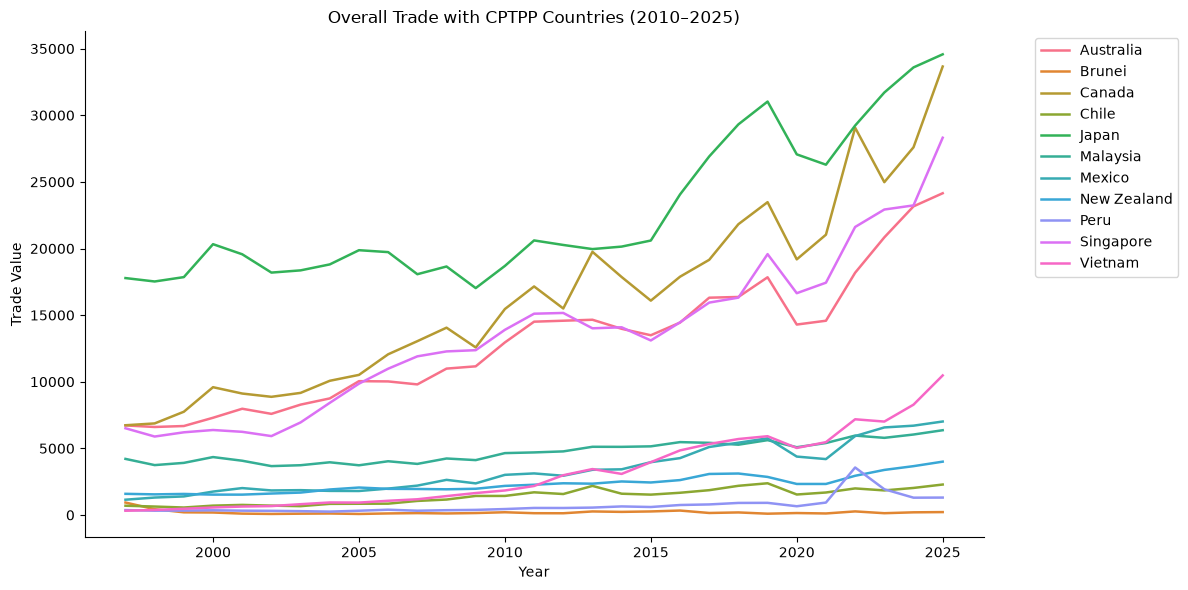

In [17]:
#import seaborn as sns
#import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df_cptpp,
    x="year",
    y="overall_trade",
    hue="Country",
    linewidth=1.8
)

plt.title("Overall Trade with CPTPP Countries (2010–2025)")
plt.ylabel("Trade Value")
plt.xlabel("Year")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

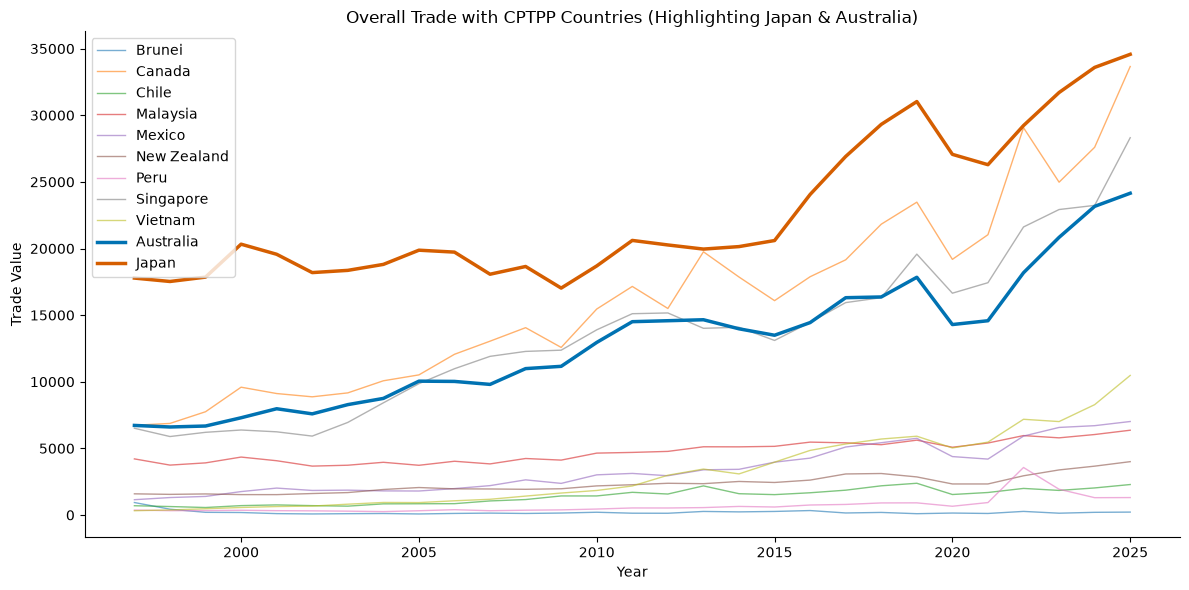

In [19]:
highlight = ["Japan", "Australia"]

df_cptpp["highlight"] = df_cptpp["Country"].isin(highlight)

plt.figure(figsize=(12, 6))

# Grey background lines
sns.lineplot(
    data=df_cptpp[~df_cptpp["highlight"]],
    x="year",
    y="overall_trade",
    hue="Country",
    color="lightgrey",
    linewidth=1,
    alpha=0.6
)

# Highlighted lines
sns.lineplot(
    data=df_cptpp[df_cptpp["highlight"]],
    x="year",
    y="overall_trade",
    hue="Country",
    palette=["#0072B2", "#D55E00"],  # FT-ish colours
    linewidth=2.5
)

plt.title("Overall Trade with CPTPP Countries (Highlighting Japan & Australia)")
plt.ylabel("Trade Value")
plt.xlabel("Year")
plt.legend(title="")
sns.despine()
plt.tight_layout()
plt.show()
